In [ ]:
library(stats)
library(tidyverse)
library(ggplot2)
library(patchwork)
library(car)


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




# Model is correctly specified


## Omitted variables


In [55]:
set.seed(1)
n <- 100
x1 <- rnorm(n, mean = 5, sd = 2)
x2 <- rpois(n, lambda = 10)
y <- 3 + 2 * x1 + 1.5 * x2 + rnorm(n, mean = 0, sd = 2) # The observed data is a function of the 2 variables x1 and x2

df <- data.frame(x1 = x1, x2 = x2, y = y)
head(df)


,x1,x2,y
,<dbl>,<int>,<dbl>
1,3.747092,8,19.57877
2,5.367287,10,28.92469
3,3.328743,7,21.85282
4,8.190562,6,25.13239
5,5.659016,15,39.63516
6,3.359063,12,26.63461


In [56]:
model1 <- lm(formula = y ~ x1, data = df)
summary(model1)



Call:
lm(formula = y ~ x1, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.8889  -4.1194  -0.9054   3.3329  12.1912 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  15.9867     1.6408   9.743 4.37e-16 ***
x1            2.2837     0.2975   7.676 1.24e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.318 on 98 degrees of freedom
Multiple R-squared:  0.3755,	Adjusted R-squared:  0.3691 
F-statistic: 58.93 on 1 and 98 DF,  p-value: 1.236e-11


In [57]:
model2 <- lm(formula = y ~ x1 + x2, data = df)
summary(model2)



Call:
lm(formula = y ~ x1 + x2, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.7222 -1.3881 -0.0275  1.2055  4.9118 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.40647    0.89173   2.699  0.00821 ** 
x1           2.10528    0.11972  17.585  < 2e-16 ***
x2           1.51002    0.06681  22.601  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.135 on 97 degrees of freedom
Multiple R-squared:  0.9003,	Adjusted R-squared:  0.8983 
F-statistic: 438.1 on 2 and 97 DF,  p-value: < 2.2e-16


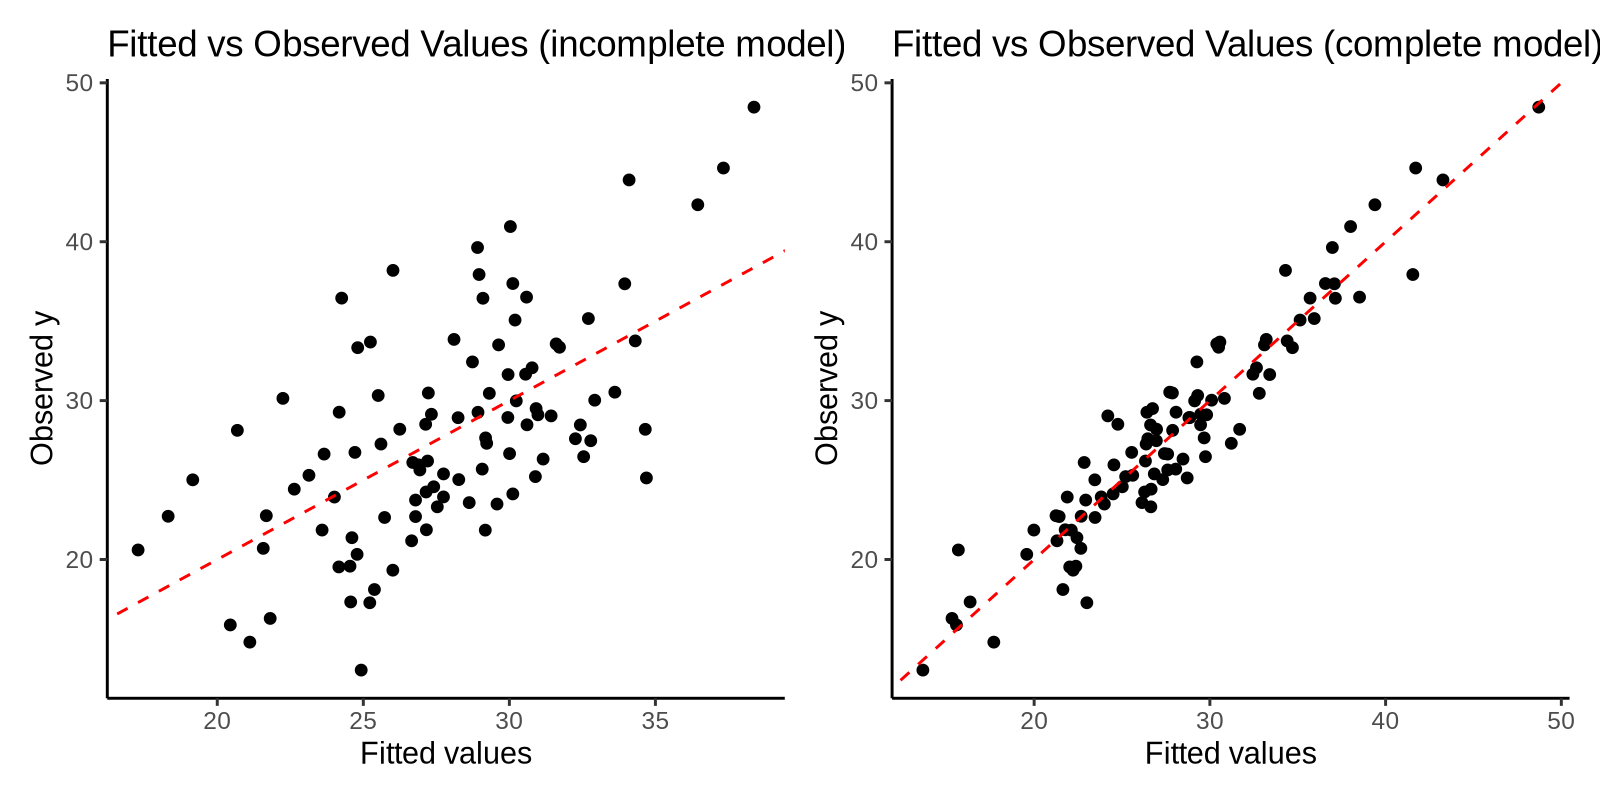

In [58]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)

df$fitted <- fitted(model1)
plt1 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Observed y", title = "Fitted vs Observed Values (incomplete model)") +
    theme_classic()

df$fitted <- fitted(model2)
plt2 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Observed y", title = "Fitted vs Observed Values (complete model)") +
    theme_classic()

plt1 + plt2


- If the fitted values correlate well with the observed values, the model is more likely to not omit important variables


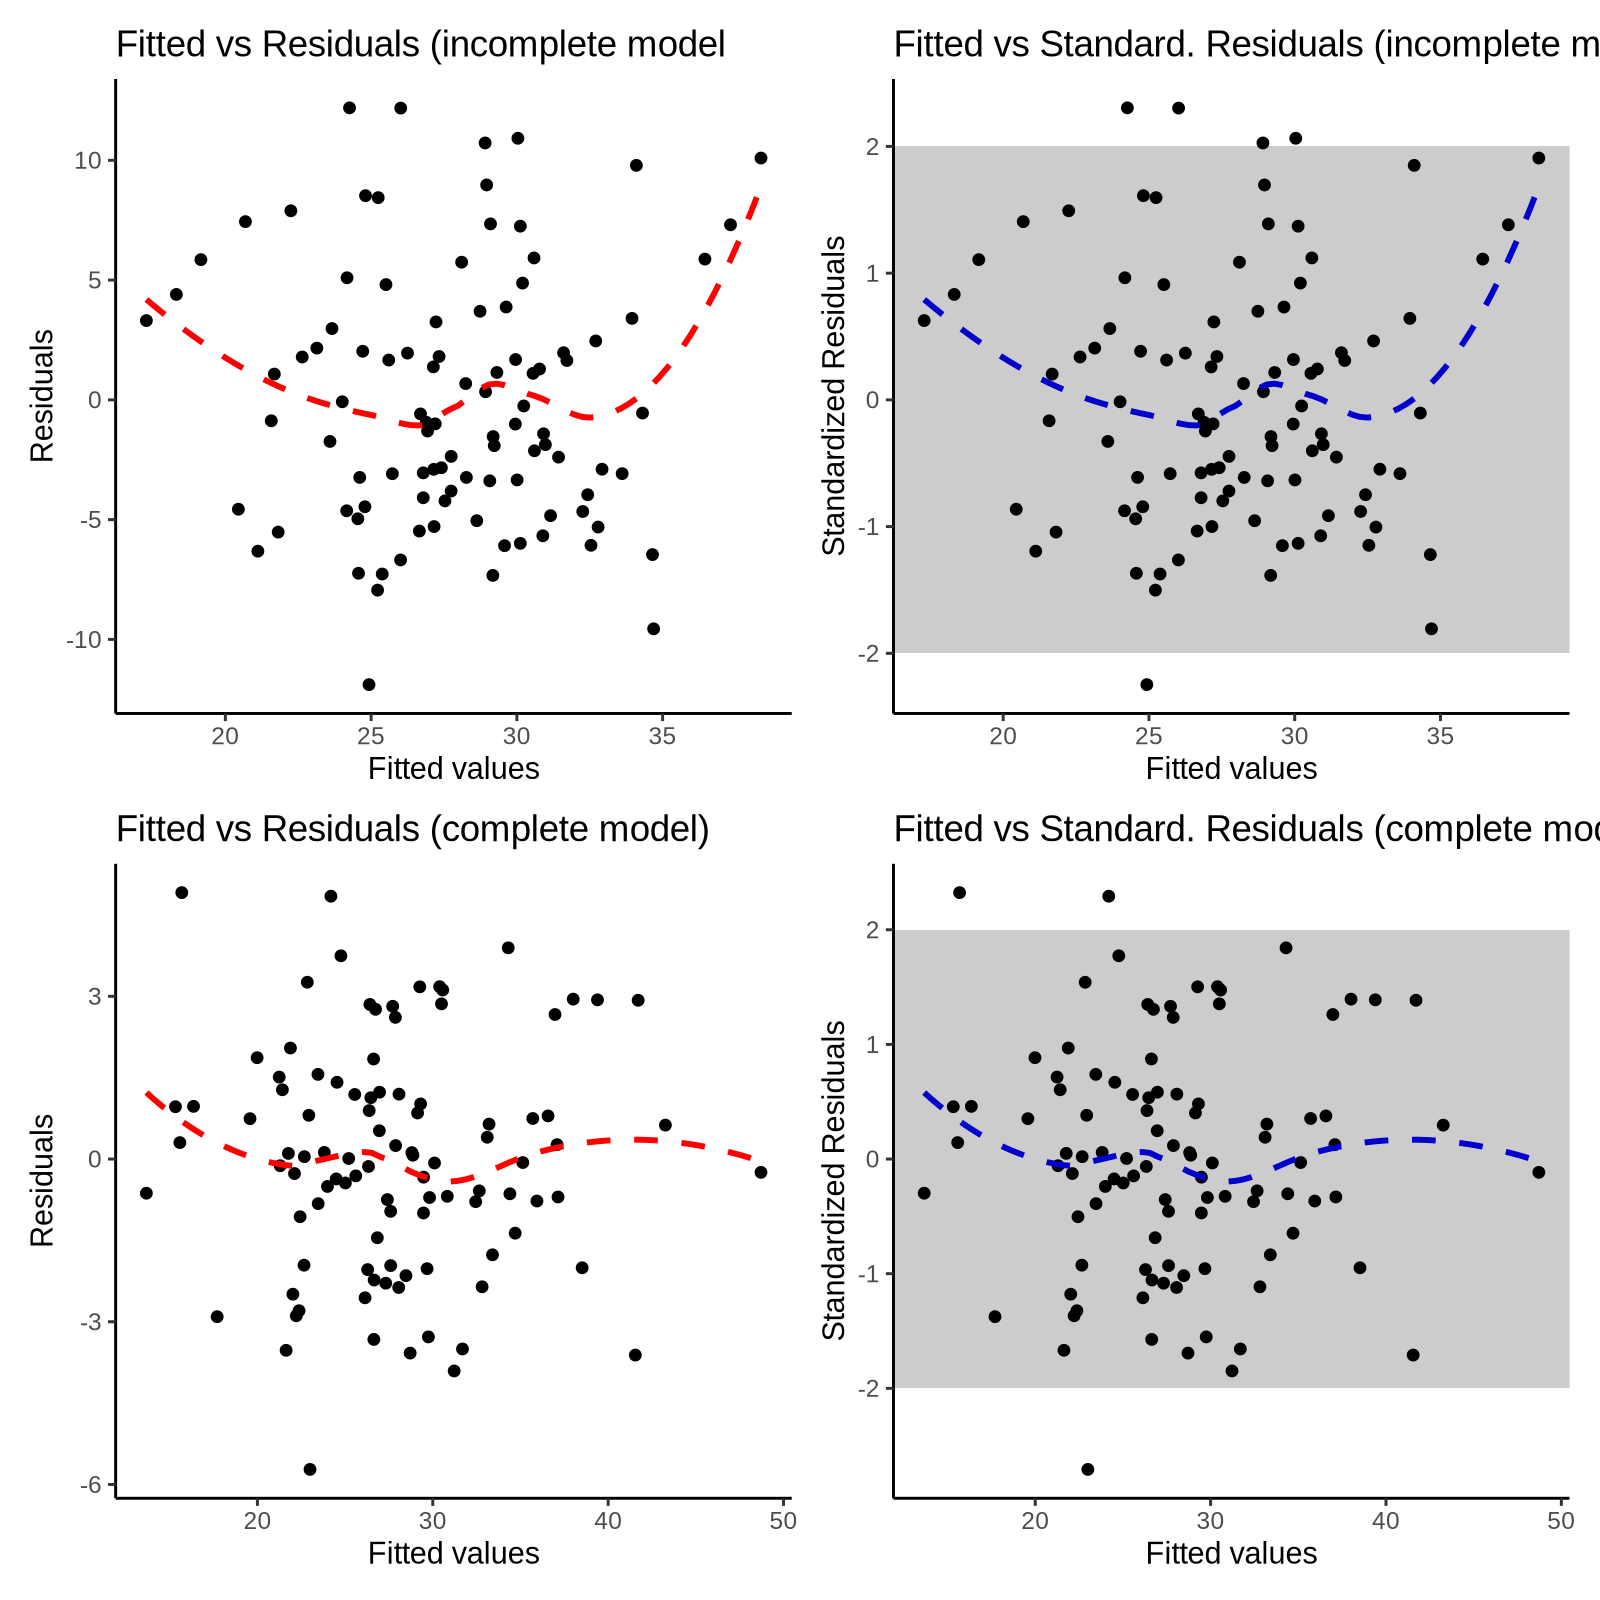

In [59]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)

df$fitted <- fitted(model1)
df$residuals <- residuals(model1)
df$residuals_standardized <- residuals(model1) / sd(residuals(model1))

plt1 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Residuals", title = "Fitted vs Residuals (incomplete model") +
    theme_classic()

plt2 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (incomplete model)") +
    theme_classic()

df$fitted <- fitted(model2)
df$residuals <- residuals(model2)
df$residuals_standardized <- residuals(model2) / sd(residuals(model2))

plt3 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Residuals", title = "Fitted vs Residuals (complete model)") +
    theme_classic()

plt4 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (complete model)") +
    theme_classic()


(plt1 + plt2) / (plt3 + plt4)


- The residuals are much smaller overall in the complete model, and the lowess follows closer to 0
- but without knowing the real data it would be difficult to say if the incomplete model explains most of the effect just by those plots


`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


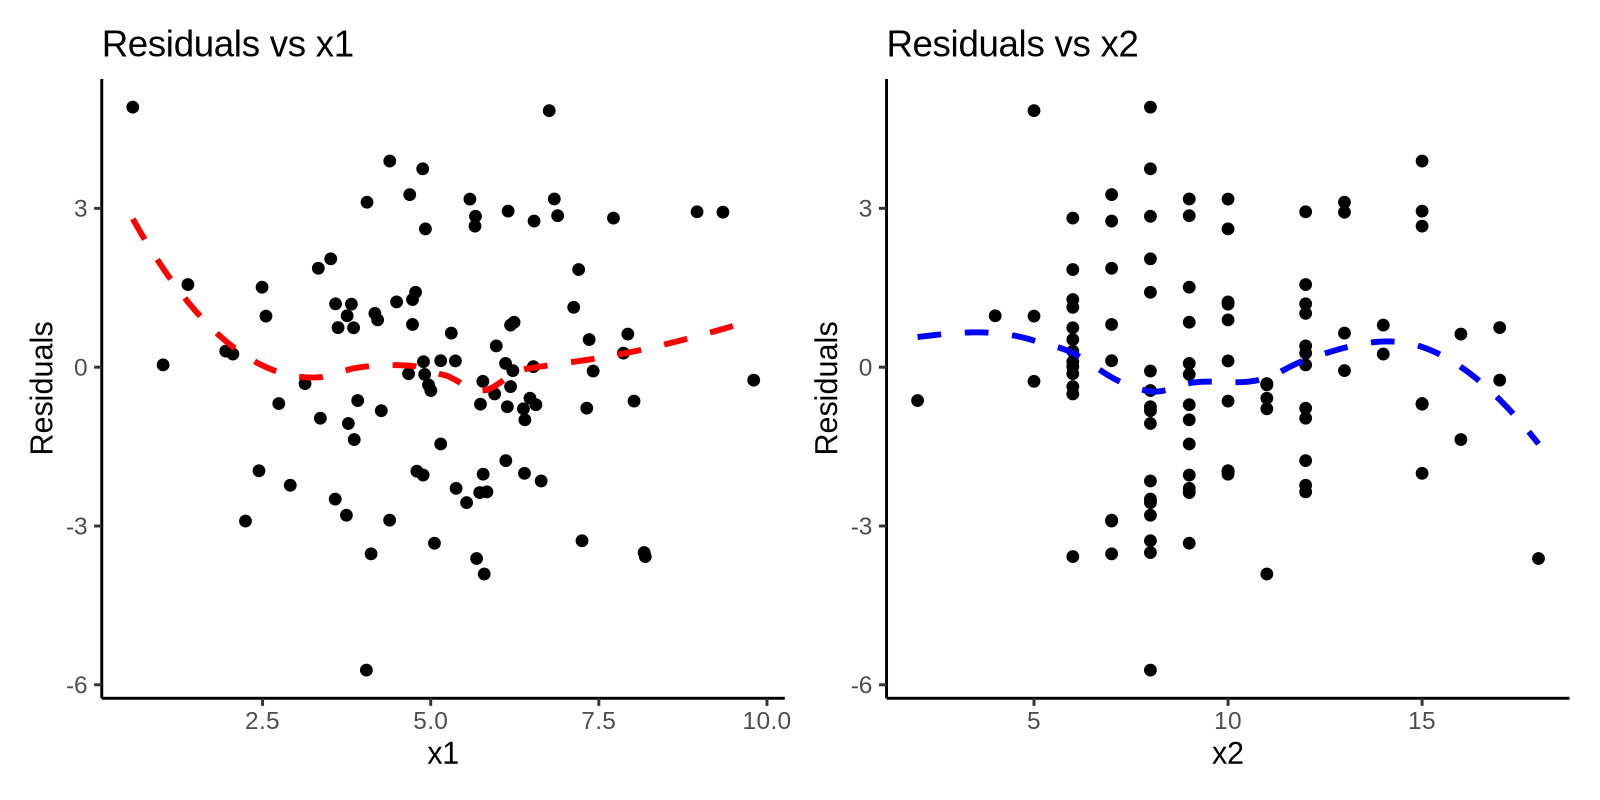

In [60]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)

plt_x1 <- ggplot(df, aes(x = x1, y = residuals)) +
    geom_point() +
    geom_smooth(method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "x1", y = "Residuals", title = "Residuals vs x1") +
    theme_classic()

plt_x2 <- ggplot(df, aes(x = x2, y = residuals)) +
    geom_point() +
    geom_smooth(method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    labs(x = "x2", y = "Residuals", title = "Residuals vs x2") +
    theme_classic()

plt_x1 + plt_x2
